# 💡 Session 2 - Fine-tuning BERT for Graph Classification

Welcome to Session 2! 👋

---

🎯 **What you’ll learn in this session:**

- How to use and fine-tune a pre-trained encoder-only LLM — BERT
- How to handle structured data formats such as graphs
- How special tokens and pooling layers work in BERT

---

In this session, we’ll dive into fine-tuning a pre-trained **encoder-only language model (BERT)** for a **graph classification** task.

Graphs (or Knowledge Graphs) are structured representations of information, typically expressed as triples in the form of  
`(subject, predicate, object)`.

The dataset contains graphs from **16 different categories**, such as *Airports*, *Companies*, *Foods*, etc.  
Your goal is to fine-tune BERT to predict the correct category for each input graph.

---

Let’s get started! 🚀


## Section 0 - Environment Setup

In [ ]:
!pip install datasets -q
!pip install tqdm -q

In [ ]:
import os
import re
import torch
import random
import numpy as np
from datasets import Dataset, DatasetDict, load_dataset
from nltk.tokenize import sent_tokenize
import nltk
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    default_data_collator
)

nltk.download('punkt_tab')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

## Section 1 - Load WebNLG Dataset

Firstly, we load WebNLG dataset from [HuggingFace](https://huggingface.co/datasets/webnlg-challenge/web_nlg).

**Hint:** Check the `02D_hf_transformers.ipynb` file for help with Ex1, 2 and 3

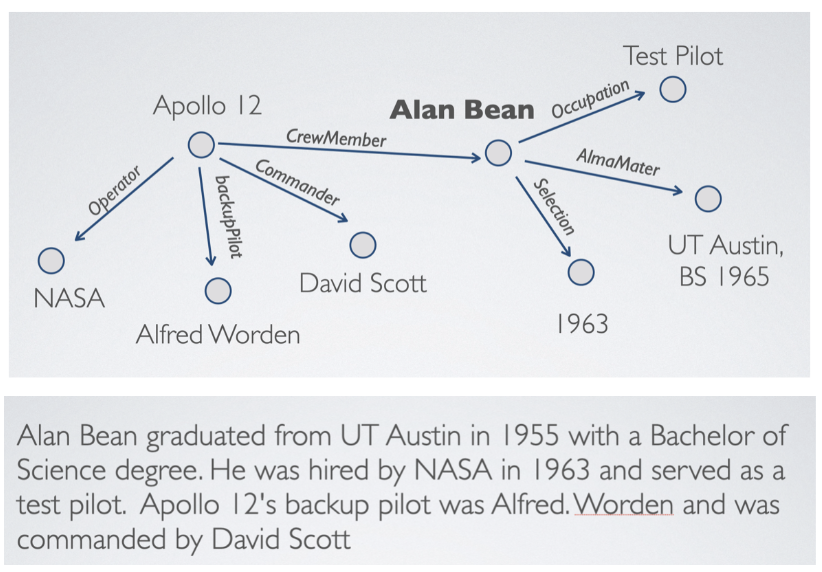

#### Ex 1: Getting the data
- Load the "webnlg-challenge/web_nlg", "release_v3.0_en" dataset from Hugging Face

In [ ]:
# Load WebNLG dataset from HuggingFace

## YOUR CODE HERE

#### Ex2: Look at the data
- Print out the datasets splits and examine the content of each split

In [ ]:
## YOUR CODE HERE

#### Ex3. Print out the first instance of the train split

In [ ]:
## YOUR CODE HERE

## Section 2 - Pre-processing, Creating a Dataset

The goal is to create a dataset that matches the format expected by the BERT model. In practice, we need to convert the WebNLG dataset into a dictionary with keys (['labels', 'input_ids', 'token_type_ids', 'attention_mask']). 

We provide skeleton code below. Your task is to fill the missing code.

In [ ]:
def from_camel(s: str) -> str:
    """
    Convert a camelCase string into a space-separated lowercase string.
    Example: birthPlace -> 'birth place'
    """
    return re.sub(r'([A-Z])', r' \1', s).lower()

def to_camel(s: str) -> str:
    """
    Convert a space-separated or snake_case string to camelCase.
    Example: city_served -> cityServed
    """
    s = re.sub(r"(_|-)+", " ", s).title().replace(" ", "")
    return s[0].lower() + s[1:]

def linearize_graph(triple_list):
    """
    Convert a list of triples into a single linearized string, e.g.:
    ['Aarhus_Airport | cityServed | "Aarhus, Denmark"']
      -> '[S] Aarhus Airport [P] cityServed [O] Aarhus, Denmark'
    """
    linearized_graph = ""
    for triple in triple_list:
        sub, pred, obj = triple[0].split(" | ")
        sub = sub.replace("_", " ").strip('"')
        pred = to_camel(from_camel(pred))
        obj = obj.replace("_", " ").strip('"')
        linearized_graph += f" [S] {sub} [P] {pred} [O] {obj}"
    return linearized_graph.strip()


We should make sure that the data format  conforms to the model(BERT) [input format](https://huggingface.co/docs/transformers/model_doc/bert#transformers.BertForSequenceClassification):
- `input_ids` is in need.
- others are optional.

#### Ex4. Create two mappings to go from labels to integers and back
- `label2id` should map each category mentioned in the `category` field of the WebNLG dataset to a separate integer
- `id2label` is the reverse mapping

In [ ]:
# Create label mapping
## YOUR CODE HERE

#### Ex5. Fill in the missing code below

In [ ]:
from datasets import Dataset
from transformers import BertTokenizer
from torch.utils.data import DataLoader

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def create_webnlg_hf_dataset(raw_split_data, tokenizer, label2id, max_length=128):
    """
    Convert raw WebNLG data into a Hugging Face Dataset suitable for Trainer.

    Args:
        raw_split_data (List[Dict]): e.g. webnlg_data["train"]
        tokenizer (PreTrainedTokenizer): e.g. BertTokenizer
        label2id (Dict[str, int]): e.g. {"Airport": 0, "Astronaut": 1, ...}
        max_length (int): Maximum sequence length for tokenization

    Returns:
        Dataset: A Hugging Face Dataset with tokenized "input_ids", "attention_mask", and "labels".
    """
    # 1) Make raw split data into list of dict
     """
     For each instance in `raw_split_data`:
     - extract the mtriple_set and linearise it (cf. linearize_graph function provided above)
     - extract the corresponding category (note that the raw_split_data to the fn we are defining is the train split of the webnlg data)
     - convert the category to its matching id  (use the label2id function you defined in Ex4)
     - store the result in a list of dictionaries of the form {"text": linearised_graph, "label": label_id}
     """

    ## YOUR CODE HERE

    # 2) Convert to HF Dataset
    # from_list is a HF method which will create a Dataset object

    ds = Dataset.from_list(processed)

    # 3) Tokenization
    def tokenize_fn(batch):
        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=max_length
        )

    ds = ds.map(tokenize_fn, batched=True)

    # 4) Remove "text"
    ds = ds.remove_columns(["text"])  # Only keep input_ids, attention_mask, label
    # Rename
    ds = ds.rename_column("label", "labels")

    return ds


#### Ex6. Creating training and validation set 
- Using the `create_webnlg_hf_dataset` function, create train and valisation datasets
- Create a smaller training set (to speed up training) of size 3000  (use Hugging face `select` method)

In [ ]:
# Create HuggingFace Datasets
## YOUR CODE HERE

# small subset (TO SPEED UP THE TRAINING and SHOW UP THE PROGRESS)
# If you would like to have better performance, of course, use the full training set

## YOUR CODE HERE

In [ ]:
train_ds[0].keys()

## Section 3 - Fine-tuning BERT

In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

In [ ]:
# Define compute_metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

In [ ]:
from math import ceil
train_size = len(fast_train_ds)
batch_size = 16  # per_device_train_batch_size
steps_per_epoch = ceil(train_size / batch_size)
eval_steps = int(steps_per_epoch * 0.2)

In [ ]:
# TrainingArguments
training_args = TrainingArguments(
    output_dir="./bert-graph-classifier",
    evaluation_strategy="steps",         # 👈 evaluation per (0.2*epoch) steps
    eval_steps=eval_steps,
    logging_strategy="steps",
    logging_steps=eval_steps,
    save_strategy="epoch",
    logging_dir="./logs",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    learning_rate=2e-5,
    weight_decay=0.01,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to=[],
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=fast_train_ds, # train_ds
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    data_collator=default_data_collator,
)

In [ ]:
# Train
trainer.train()

## Section 4 - Evaluation (Accuracy & F1)

In [ ]:
trainer.evaluate()

## Section 5 - Special Token

In [ ]:
# Reload tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

#### Ex6. Looking at the special tokens indices

Print out the ids of the  tokens `([S],[P],[O])` used to structure the linearised graph (Cf. the `linearize_graph` function defined at the beginning of the code )
- What do you notice ?

Use the [convert_tokens_to_ids](
https://huggingface.co/docs/transformers/en/main_classes/tokenizer#transformers.PreTrainedTokenizer.convert_tokens_to_ids) Function

In [1]:
### YOUR CODE HERE

#### Ex7. Adding Special Tokens to the vocabulary
- First print the size of the vocabulary (use the tokenize `vocab_size` attribute)
- Create a dictionnary with key "additional_special_tokens" and value the list of tokens you want to add (tokens for subject, predicate and object
- Add these special tokens to the vocabulary using the `add_special_tokens` method
- Use len(tokenizer) to retrieve the new vocab size of the tokenizer (tokenizer.vocab_size refers to the original vocab size of tokenizer, which cannot be modified)

[add_special_tokens method](https://huggingface.co/docs/transformers/en/main_classes/tokenizer#transformers.PreTrainedTokenizer.add_special_tokens)

In [ ]:
# Add special tokens
## YOUR CODE HERE

#### Ex8. Print the index of the new tokens you just added

Use the `convert_tokens_to_ids` lethod from HF.

In [ ]:
print(tokenizer.convert_tokens_to_ids("[S]"))
print(tokenizer.convert_tokens_to_ids("[P]"))
print(tokenizer.convert_tokens_to_ids("[O]"))

In [ ]:
# Create HuggingFace Datasets
train_ds = create_webnlg_hf_dataset(webnlg_data["train"], tokenizer, label2id)
val_ds = create_webnlg_hf_dataset(webnlg_data["dev"], tokenizer, label2id)

# small subset (TO SPEED UP THE TRAINING and SHOW UP THE PROGRESS)
# If you would like to have better performance, of course, use the full training set
fast_train_ds = train_ds.shuffle(seed=42).select(range(2000))

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

In [ ]:
# ===== IMPORTANT !!! =====
# Remember to resize your model to fit in your new vocab corpus
model.resize_token_embeddings(len(tokenizer))

In [ ]:
# We keep using the same trainer
# Train
trainer.train()

**Notes:** We can observe that the model trained with the version that incorporates the special token performs a bit better

## Section 6 - Pooling layers

I don't implement this part, as this should overwrite the BERT model, however, our aim is to introduce how to use huggingface library to finetune BERT. The model overwriting is a little difficult for students.

## Optional Reading - Overwrite and Extend BERT as MoE models
We compare the standard fine-tuned BERT with BERT-based MoE models, and demonstrate the MoE variant with better performance.

Specifically and technically, we show how to overwrite a BERT model and change its pooling layers to CLS token/mean/max, and also how to make a complex neural network (such as MoE) based on BERT encoders. All implementations rely mainly on the library `transformers`.

Notebook link: [Github Page](https://github.com/MeloS7/NLP_by_hand/blob/main/Classification/MoE_for_graph_classification.ipynb)

It was developped with memory-larger GPU on Grid5k, so you can not run it on Colab.
